In [1]:
import numpy as np
import pandas as pd
import timecorr as tc
import hypertools as hyp
import supereeg as se
from matplotlib import pyplot as plt
import seaborn as sns
import os
from glob import glob as lsdir
from scipy.io import loadmat as load
import numba
import nltools as nlt
import nilearn as nl
import nibabel as nib
from nilearn.input_data import NiftiMasker
from scipy.spatial.distance import pdist, cdist, squareform
from collections import deque

%matplotlib inline

In [2]:
datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
nii_files = lsdir(os.path.join(datadir, '*.nii'))
regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))
cluster_masks = os.path.join('clusters', 'k50_2mm_gm_split_cleaned.nii.gz')

In [3]:
def apply_mask(data, mask):
    data = data.get_data()
    mask = mask.get_data()
    
    T = data.shape[3]
    K = mask.shape[3]    
    Y = np.zeros([T, K])
    
    for k in np.arange(K):
        roi_mask = mask[:, :, :, k]
        roi_inds = np.where(roi_mask)
        Y[:, k] = np.mean(data[roi_inds[0], roi_inds[1], roi_inds[2], :], axis=0)
    return Y

In [4]:
def plot_cluster_centers(mask, node_color='k', node_size=10, **kwargs):
    mask_bo = se.Brain(mask)
    data = mask_bo.data
    locs = mask_bo.locs
    
    centers = np.zeros([data.shape[0], locs.shape[1]])
    for k in np.arange(data.shape[0]):
        centers[k, :] = locs.iloc[np.where(data.iloc[k, :] == 1)[0], :].mean(axis=0)
    
    nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_color=node_color, node_size=node_size, **kwargs)
    return centers

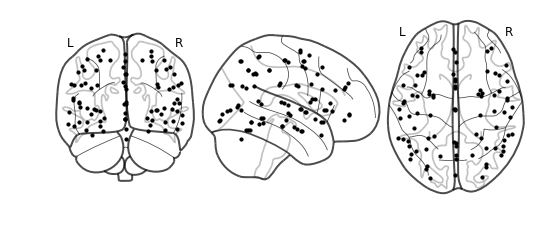

In [5]:
mask = nib.load(cluster_masks)
c = plot_cluster_centers(mask)

In [6]:
def package_data(masked_data, nii_files, regressor_files):
    nii_subjs = list(map(lambda f: f.split('/')[-1][:-len('.nii')], nii_files))
    reg_subjs = list(map(lambda f: f.split('/')[-1][:-len('_regs_results.mat')], regressor_files))
    
    data = []
    for i, s in enumerate(nii_subjs):
        try:
            j = np.ravel(np.where(np.array(list(map(lambda x: x == s, reg_subjs)))))[0]
            print(f'matching {s} with {regressor_files[j]}')
            regmat = load(regressor_files[j])
            data.append({'data': masked_data[i], 'regmat': regmat['all_regressors'], 'mvpa': regmat['results']})
        except:
            print(f'missing data for {s}')
    return data

In [7]:
data_fname = os.path.join('data', 'preprocessed.npz')
if os.path.exists(data_fname):
    print('loading preprocessed data from disk...')
    data = np.load(data_fname)['data']
else:
    print('preprocessed data...')
    masked_data = list(map(lambda f: apply_mask(nib.load(f), mask), nii_files))
    data = package_data(masked_data, nii_files, regressor_files)
    np.savez(os.path.join('data', 'preprocessed.npz'), data=data)

loading preprocessed data from disk...


In [8]:
regressors_key = ['Present list A', 
                  'Present list B (R)', 
                  'Present list B (F)',
                  'Recall list A (R)',
                  'Recall list B (R)', 
                  'Recall list A (F)',
                  'Recall list B (F)',
                  'Present localizer list 1',
                  'Recall localizer list 1',
                  'Present localizer list 2',
                  'Recall localizer list 2',
                  'Present scene localizer image',
                  'Present objects localizer image',
                  'Present scrambled scene localizer image']
present_a = [0]
present_b = [1, 2]
forget = [2, 5, 6]
remember = [1, 3, 4]

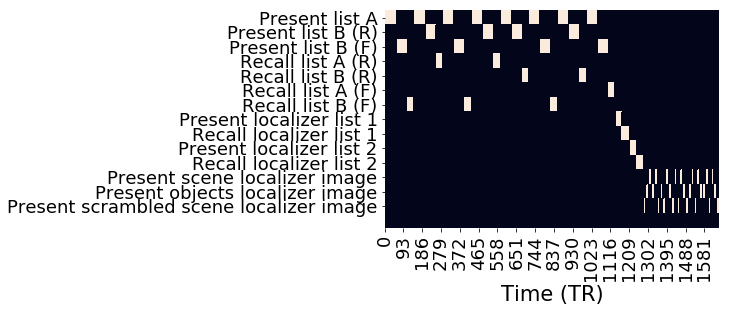

In [9]:
#experiment labels from participant 0
h = sns.heatmap(data[0]['regmat'], cbar=False)
h.set_yticks(np.arange(len(regressors_key)) + 0.5)
h.set_yticklabels(regressors_key)
plt.yticks(rotation=0);
plt.xlabel('Time (TR)');

In [10]:
def get_keys(inds):
    keys = []
    for i in inds:
        keys.append(regressors_key[i])
    return keys

In [11]:
print(get_keys(present_a))
print(get_keys(present_b))
print(get_keys(remember))
print(get_keys(forget))

['Present list A']
['Present list B (R)', 'Present list B (F)']
['Present list B (R)', 'Recall list A (R)', 'Recall list B (R)']
['Present list B (F)', 'Recall list A (F)', 'Recall list B (F)']


In [12]:
def get_bounds(x): #x is a line from a regressors matrix
    diffs = np.diff(np.array(x, dtype=np.float)) #strange things happen when x is an array of ints
    return np.where(diffs == 1)[0], np.where(diffs == -1)[0] #event starts, ends

In [13]:
def get_events(data, event_times, before=25, after=25):
    '''
    return the data, centered on each event_time. the resulting matrix is of shape
    (before + after + 1) by data.shape[1] by len(event_times).  if an event starts
    or ends too close to the beginning or end of the given data, the slice of that
    event's representation in the result will contain nans to reflect the missing
    data.
    '''
    
    x = np.multiply(np.nan, np.zeros([before + after + 1, data.shape[1], len(event_times)]))
    for i, t in enumerate(event_times):
        start_time = t - before - 1
        end_time = t + after
        
        if start_time >= 0:
            start_ind = 0
        else:
            start_ind = np.abs(start_time)
            start_time = 0
        
        if end_time <= data.shape[0]:
            end_ind = before + after + 1
        else:
            end_ind = end_time - data.shape[0]
            end_time = data.shape[0]
        
        x[start_ind:end_ind, :, i] = data[start_time:end_time, :]
    return x

In [14]:
def get_network_dynamics(x, rows, offset=-2, before=25, after=25, **kwargs):
    def copier(a):
        if type(a) == list:
            return list(map(copier, a))
        return np.copy(a)
    
    if not (type(rows) == list):
        rows = [rows]
        delist = True
    else:
        delist = False
    
    nets = []
    debug_a = [] #data
    debug_b = [] #means
    for r in rows:
        next_data = list(map(lambda y: get_events(y['data'], get_bounds(y['regmat'][r, :])[0] + offset, before=before, after=after), x))
        next_means = list(map(lambda y: np.nanmean(y, axis=2), next_data))
        nets.append(tc.timecorr(copier(next_means), **kwargs))
        
        debug_a.append(next_data)
        debug_b.append(next_means)
    
    if delist:
        return nets[0], debug_a[0], debug_b[0]
    else:
        return nets, debug_a, debug_b

In [15]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [16]:
def ribbon(x, y, lb, ub=None, color='k', alpha=0.5):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

In [17]:
def event_ribbon(x, ts=None, color='k', alpha=0.5):
    if ts is None:
        ts = np.arange(-(x.shape[0] - 1)/2, (x.shape[0] - 1)/2 + 1) #assume centered data
    
    m = np.nanmean(x, axis=1)
    sem = np.divide(np.nanstd(x, axis=1), np.sqrt(x.shape[1]))
    
    return ribbon(ts, m, sem, sem, color=color, alpha=alpha)

In [18]:
#bug: something is going wrong here...these should all be the same
r_f_nets1, a1, b1 = get_network_dynamics(data, [1, 2], weights_function=tc.gaussian_weights, weights_params={'var': 5}, combine=tc.helpers.corrmean_combine)
r_f_nets2, a2, b2 = get_network_dynamics(data, [1, 2], weights_function=tc.gaussian_weights, weights_params={'var': 5}, combine=tc.helpers.corrmean_combine)
#r_f_nets3, a3, b3 = get_network_dynamics(data, [1, 2], weights_function=tc.gaussian_weights, weights_params={'var': 5}, combine=tc.helpers.corrmean_combine)
#r_f_nets4, a4, b4 = get_network_dynamics(data, [1, 2], weights_function=tc.gaussian_weights, weights_params={'var': 5}, combine=tc.helpers.corrmean_combine, rfun)

In [19]:
test_data = list(map(lambda x: np.cumsum(np.random.randn(100, 10), axis=0), np.arange(5)))
for i in np.arange(len(test_data)):
    test_data[i][np.random.rand(test_data[i].shape[0], test_data[i].shape[1]) < 0.1] = np.nan

In [20]:
tc1 = tc.timecorr(test_data, weights_function=tc.gaussian_weights, weights_params={'var': 5}, combine=tc.helpers.corrmean_combine)

In [21]:
tc2 = tc.timecorr(test_data, weights_function=tc.gaussian_weights, weights_params={'var': 5}, combine=tc.helpers.corrmean_combine)

In [22]:
np.array(tc1).shape

(100, 55)

In [23]:
np.array(tc2).shape

(100, 55)

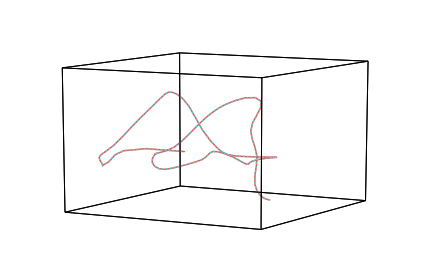

In [24]:
hyp.plot([np.array(tc1), np.array(tc2)], ['-', ':'])

In [25]:
def allclose_wrapper(x1, x2):
    def nanremove(x):
        if type(x) == list:
            return list(map(nanremove, x))
        x[np.isnan(x)] = 0
        return np.copy(x)
    
    def allclose_helper(x, y):
        if type(x) == list:
            return np.all(np.array(list(map(lambda a, b: allclose_helper(a, b), x, y))))        
        return np.allclose(x, y)
    
    x1 = nanremove(x1)
    x2 = nanremove(x2)
    
    return allclose_helper(x1, x2)

In [26]:
allclose_wrapper(b1, b2)

True

In [27]:
r_f_nets1[0].shape

(51, 3916)

In [28]:
r_f_nets2[0].shape

(51, 3916)

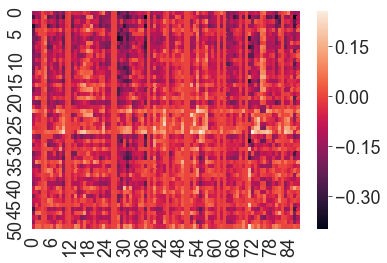

In [29]:
sns.heatmap(b1[0][0])

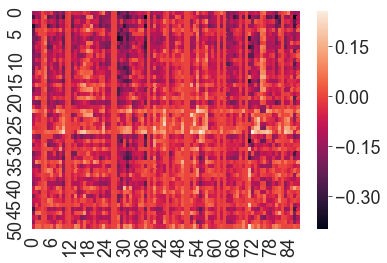

In [30]:
sns.heatmap(b2[0][0])

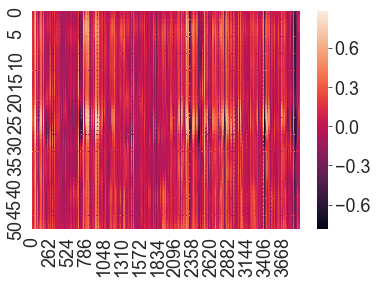

In [31]:
sns.heatmap(r_f_nets1[0])

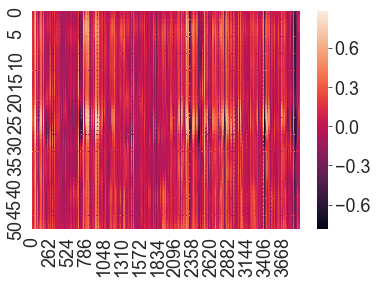

In [38]:
sns.heatmap(r_f_nets2[0])

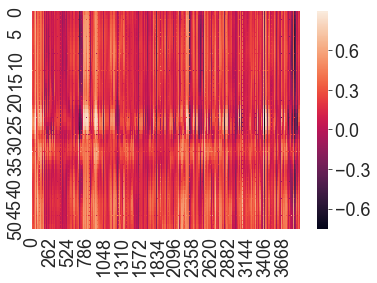

In [32]:
sns.heatmap(r_f_nets1[1])

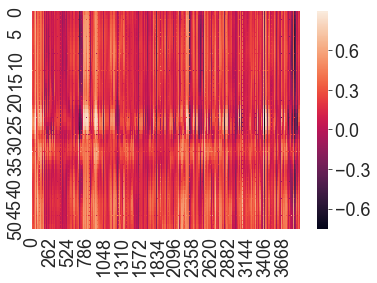

In [39]:
sns.heatmap(r_f_nets2[1])

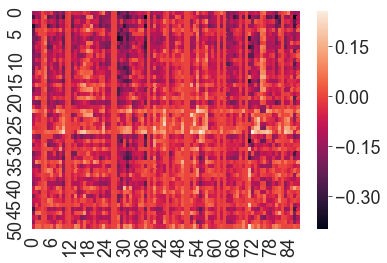

In [34]:
sns.heatmap(b1[0][0])

In [35]:
np.allclose(np.nansum(np.stack((b2[1][3], -b1[1][3]), axis=2), axis=2), 0)

True

Text(0, 0.5, 'Average full-brain ISFC')

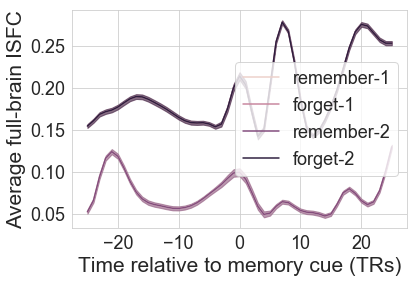

In [37]:
colors = sns.cubehelix_palette(n_colors=4)
event_ribbon(r_f_nets1[0], color=colors[0]);
event_ribbon(r_f_nets1[1], color=colors[1]);
event_ribbon(r_f_nets2[0], color=colors[2]);
event_ribbon(r_f_nets2[1], color=colors[3]);
#event_ribbon(r_f_nets3[0], color=colors[4]);
#event_ribbon(r_f_nets3[1], color=colors[5]);
plt.legend(['remember-1', 'forget-1', 'remember-2', 'forget-2'])

plt.xlabel('Time relative to memory cue (TRs)')
plt.ylabel('Average full-brain ISFC')

In [ ]:
#debugging timecorr issue...

In [ ]:
x = np.random.randn(100, 10)

In [ ]:
f1 = hyp.tools.format_data(x)
f2 = hyp.tools.format_data(x)
f3 = hyp.tools.format_data(x)

In [ ]:
sns.heatmap(f1[0])

In [ ]:
sns.heatmap(f2[0])

In [ ]:
sns.heatmap(f3[0])

In [ ]:
#doesn't seem to be an issue with format_data...